# COAD Somatic MAF Analysis

## Project Overview

This notebook analyzes open-access somatic mutation data from TCGA-COAD, the TCGA colon adenocarcinoma cohort. The goal is to practice clinically oriented cancer genomics analysis using Mutation Annotation Format (MAF) data.

COAD was selected because colorectal cancer provides a strong context for exploring mismatch repair deficiency, microsatellite instability, hypermutation, tumor mutational burden-style patterns, and clinically relevant molecular oncology genes.

This project is for educational and portfolio purposes only. It is not intended for diagnosis, treatment decisions, or clinical reporting.

## Planned Workflow

1. Import Python packages.
2. Load open-access TCGA-COAD MAF data.
3. Inspect the dataset structure.
4. Summarize the number of variants and tumor samples.
5. Summarize mutation classifications and variant types.
6. Identify frequently mutated genes.
7. Calculate mutation counts per sample as a simple tumor mutation burden-style proxy.
8. Flag selected colorectal cancer, mismatch repair, polymerase proofreading, and clinically relevant genes.
9. Identify high-mutation outlier samples using an exploratory IQR-based threshold.
10. Export summary tables and figures.
11. Document interpretation and limitations.

In [1]:
# Core packages
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

In [2]:
# Define project paths
project_dir = Path("..")
data_dir = project_dir / "data"
results_dir = project_dir / "results" / "coad"

# Create results directory if it does not already exist
results_dir.mkdir(parents=True, exist_ok=True)

data_dir, results_dir

(WindowsPath('../data'), WindowsPath('../results/coad'))

In [3]:
# Directory containing downloaded COAD MAF files
coad_maf_dir = data_dir / "coad_maf"

# Find all compressed MAF files
coad_maf_files = sorted(coad_maf_dir.rglob("*.maf.gz"))

print(f"Found {len(coad_maf_files)} COAD MAF files.")


Found 450 COAD MAF files.


In [4]:
if len(coad_maf_files) > 0:
    maf_list = []

    for file in coad_maf_files:
        temp_maf = pd.read_csv(file, sep="\t", comment="#", low_memory=False)
        temp_maf["source_file"] = file.name
        maf_list.append(temp_maf)

    coad_maf = pd.concat(maf_list, ignore_index=True)

    print(f"Loaded combined COAD MAF with {coad_maf.shape[0]:,} rows and {coad_maf.shape[1]:,} columns.")
else:
    coad_maf = None
    print(f"No MAF files found in: {coad_maf_dir}")

Loaded combined COAD MAF with 252,055 rows and 141 columns.


C:\Users\andre\AppData\Local\Temp\ipykernel_34648\3217084019.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  coad_maf = pd.concat(maf_list, ignore_index=True)


In [5]:
coad_maf.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,dbSNP_RS,dbSNP_Val_Status,Tumor_Sample_Barcode,Matched_Norm_Sample_Barcode,Match_Norm_Seq_Allele1,Match_Norm_Seq_Allele2,Tumor_Validation_Allele1,Tumor_Validation_Allele2,Match_Norm_Validation_Allele1,Match_Norm_Validation_Allele2,Verification_Status,Validation_Status,Mutation_Status,Sequencing_Phase,Sequence_Source,Validation_Method,Score,BAM_File,Sequencer,Tumor_Sample_UUID,Matched_Norm_Sample_UUID,HGVSc,HGVSp,HGVSp_Short,Transcript_ID,Exon_Number,t_depth,t_ref_count,t_alt_count,n_depth,n_ref_count,n_alt_count,all_effects,Allele,Gene,Feature,Feature_type,...,gnomAD_ASJ_AF,gnomAD_EAS_AF,gnomAD_FIN_AF,gnomAD_NFE_AF,gnomAD_OTH_AF,gnomAD_SAS_AF,MAX_AF,MAX_AF_POPS,gnomAD_non_cancer_AF,gnomAD_non_cancer_AFR_AF,gnomAD_non_cancer_AMI_AF,gnomAD_non_cancer_AMR_AF,gnomAD_non_cancer_ASJ_AF,gnomAD_non_cancer_EAS_AF,gnomAD_non_cancer_FIN_AF,gnomAD_non_cancer_MID_AF,gnomAD_non_cancer_NFE_AF,gnomAD_non_cancer_OTH_AF,gnomAD_non_cancer_SAS_AF,gnomAD_non_cancer_MAX_AF_adj,gnomAD_non_cancer_MAX_AF_POPS_adj,CLIN_SIG,SOMATIC,PUBMED,TRANSCRIPTION_FACTORS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,miRNA,IMPACT,PICK,VARIANT_CLASS,TSL,HGVS_OFFSET,PHENO,GENE_PHENO,CONTEXT,tumor_bam_uuid,normal_bam_uuid,case_id,GDC_FILTER,COSMIC,hotspot,RNA_Support,RNA_depth,RNA_ref_count,RNA_alt_count,callers,source_file
0,NPHP4,261734,BCM,GRCh38,chr1,5907121,5907121,+,Silent,SNP,G,G,A,NaN,NaN,TCGA-G4-6298-01A-11D-1719-10,TCGA-G4-6298-10A-01D-1719-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Somatic,NaN,NaN,NaN,NaN,NaN,NaN,931f39bf-d32d-4a90-b25e-1331b86ca697,5b0c9878-15c0-4b6d-965f-2b311742e60d,c.1605C>T,p.Ala535=,p.A535=,ENST00000378156,13/30,179,93,86,36,NaN,NaN,"NPHP4,synonymous_variant,p.A535=,ENST000003781...",A,ENSG00000131697,ENST00000378156,Transcript,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1;1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LOW,1.0,SNV,1.0,NaN,1;1,1.0,GCCTGGGCCGG,008a11c3-cf47-410d-ac52-607f72713c88,ecfed45a-c645-4193-8149-906cc56e7684,ab9cc98a-86ae-4913-bcb2-cc3aeff8abb1,NaN,COSM3689779,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,3334cc8c-9104-4637-84e4-61a4cc3b5fb3.wxs.aliqu...
1,UBE4B,10277,BCM,GRCh38,chr1,10179536,10179536,+,Missense_Mutation,SNP,C,C,T,rs758014435,NaN,TCGA-G4-6298-01A-11D-1719-10,TCGA-G4-6298-10A-01D-1719-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Somatic,NaN,NaN,NaN,NaN,NaN,NaN,931f39bf-d32d-4a90-b25e-1331b86ca697,5b0c9878-15c0-4b6d-965f-2b311742e60d,c.3821C>T,p.Thr1274Met,p.T1274M,ENST00000343090,27/28,56,33,23,22,NaN,NaN,"UBE4B,missense_variant,p.T1325M,ENST0000067272...",T,ENSG00000130939,ENST00000343090,Transcript,...,0.0,0.0,0.0,0.000009,0.0,0.000033,0.000062,gnomAD_AFR,0.000054,0.000146,0.0,0.0,0.0,0.000000,0.0,0.0,0.000031,0.0,0.0,0.000146,afr,NaN,0;1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,NaN,SNV,1.0,NaN,0;1,NaN,GCAGACGCTGA,008a11c3-cf47-410d-ac52-607f72713c88,ecfed45a-c645-4193-8149-906cc56e7684,ab9cc98a-86ae-4913-bcb2-cc3aeff8abb1,NaN,COSM1231576;COSM1231577;COSM3688836,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,3334cc8c-9104-4637-84e4-61a4cc3b5fb3.wxs.aliqu...
2,MTOR,2475,BCM,GRCh38,chr1,11213446,11213446,+,Missense_Mutation,SNP,G,G,A,rs751901845,NaN,TCGA-G4-6298-01A-11D-1719-10,TCGA-G4-6298-10A-01D-1719-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Somatic,NaN,NaN,NaN,NaN,NaN,NaN,931f39bf-d32d-4a90-b25e-1331b86ca697,5b0c9878-15c0-4b6d-965f-2b311742e60d,c.3238C>T,p.Arg1080Cys,p.R1080C,ENST00000361445,21/58,154,86,67,69,NaN,NaN,"MTOR,missense_variant,p.R1080C,ENST00000361445...",A,ENSG00000198793,ENST00000361445,Transcript,...,0.0,0.0,0.0,0.000053,0.0,0.000000,0.000053,gnomAD_NFE,0.000027,0.000024,0.0,0.0,0.0,0.000000,0.0,0.0,0.000046,0.0,0.0,0.000046,nfe,NaN,0;1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,1.0,SNV,1.0,NaN,0;1,1.0,GACACGCAGCA,008a11c3-cf47-410d-ac52-607f72713c88,ecfed45a-c645-4193-8149-906cc56e7684,ab9cc98a-86ae

In [6]:
coad_maf.shape

(252055, 141)

In [7]:
coad_maf.columns.tolist()

['Hugo_Symbol',
 'Entrez_Gene_Id',
 'Center',
 'NCBI_Build',
 'Chromosome',
 'Start_Position',
 'End_Position',
 'Strand',
 'Variant_Classification',
 'Variant_Type',
 'Reference_Allele',
 'Tumor_Seq_Allele1',
 'Tumor_Seq_Allele2',
 'dbSNP_RS',
 'dbSNP_Val_Status',
 'Tumor_Sample_Barcode',
 'Matched_Norm_Sample_Barcode',
 'Match_Norm_Seq_Allele1',
 'Match_Norm_Seq_Allele2',
 'Tumor_Validation_Allele1',
 'Tumor_Validation_Allele2',
 'Match_Norm_Validation_Allele1',
 'Match_Norm_Validation_Allele2',
 'Verification_Status',
 'Validation_Status',
 'Mutation_Status',
 'Sequencing_Phase',
 'Sequence_Source',
 'Validation_Method',
 'Score',
 'BAM_File',
 'Sequencer',
 'Tumor_Sample_UUID',
 'Matched_Norm_Sample_UUID',
 'HGVSc',
 'HGVSp',
 'HGVSp_Short',
 'Transcript_ID',
 'Exon_Number',
 't_depth',
 't_ref_count',
 't_alt_count',
 'n_depth',
 'n_ref_count',
 'n_alt_count',
 'all_effects',
 'Allele',
 'Gene',
 'Feature',
 'Feature_type',
 'One_Consequence',
 'Consequence',
 'cDNA_position',
 'C

In [8]:
n_variants = coad_maf.shape[0]
n_samples = coad_maf["Tumor_Sample_Barcode"].nunique()
n_genes = coad_maf["Hugo_Symbol"].nunique()

print(f"Number of variants: {n_variants:,}")
print(f"Number of tumor samples: {n_samples:,}")
print(f"Number of mutated genes: {n_genes:,}")

Number of variants: 252,055
Number of tumor samples: 448
Number of mutated genes: 18,649


In [9]:
mutation_class_counts = (
    coad_maf["Variant_Classification"]
    .value_counts()
    .reset_index()
)

mutation_class_counts.columns = ["Variant_Classification", "Count"]
mutation_class_counts

,Variant_Classification,Count
0,Missense_Mutation,148190
1,Silent,54170
2,Frame_Shift_Del,19004
3,Nonsense_Mutation,12060
4,Frame_Shift_Ins,5014
5,Splice_Site,2926
6,Intron,2910
7,3'UTR,1920
8,Splice_Region,1710
9,RNA,1460


In [10]:
variant_type_counts = (
    coad_maf["Variant_Type"]
    .value_counts()
    .reset_index()
)

variant_type_counts.columns = ["Variant_Type", "Count"]
variant_type_counts

,Variant_Type,Count
0,SNP,225596
1,DEL,21093
2,INS,5348
3,ONP,18


In [11]:
top_mutated_genes = (
    coad_maf["Hugo_Symbol"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_mutated_genes.columns = ["Gene", "Mutation_Count"]
top_mutated_genes

,Gene,Mutation_Count
0,TTN,1068
1,APC,524
2,MUC16,438
3,SYNE1,375
4,FAT4,264
5,TP53,260
6,RYR2,255
7,OBSCN,233
8,DST,226
9,KRAS,201


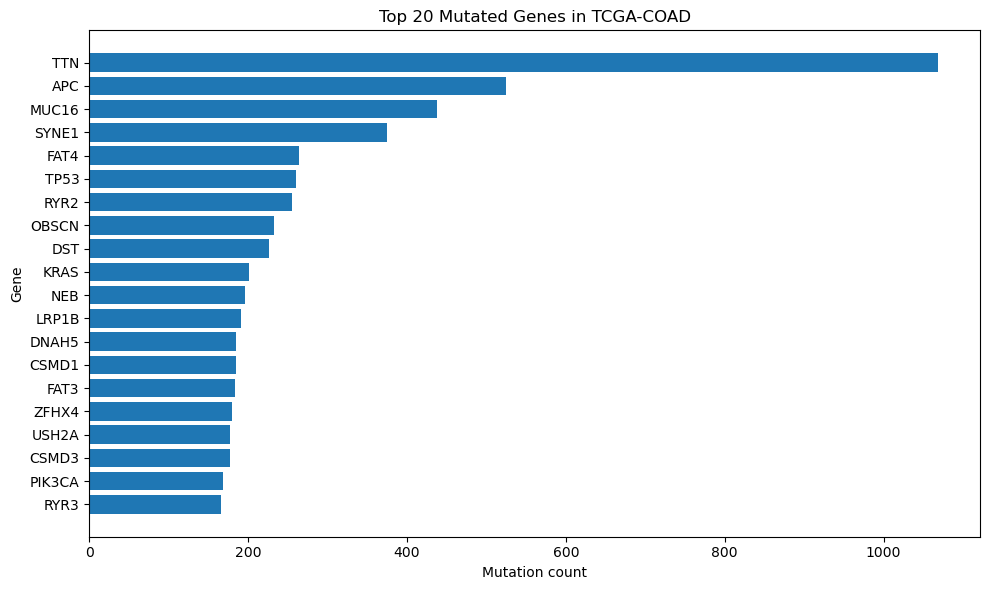

In [12]:
plt.figure(figsize=(10, 6))
plt.barh(top_mutated_genes["Gene"], top_mutated_genes["Mutation_Count"])
plt.gca().invert_yaxis()
plt.xlabel("Mutation count")
plt.ylabel("Gene")
plt.title("Top 20 Mutated Genes in TCGA-COAD")
plt.tight_layout()
plt.savefig(results_dir / "coad_top_20_mutated_genes.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
mutation_counts_per_sample = (
    coad_maf
    .groupby("Tumor_Sample_Barcode")
    .size()
    .reset_index(name="Mutation_Count")
    .sort_values("Mutation_Count", ascending=False)
)

mutation_counts_per_sample.head(20)

,Tumor_Sample_Barcode,Mutation_Count
277,TCGA-CA-6717-01A-11D-1835-10,9830
194,TCGA-AA-A010-01A-01D-A17O-10,8856
195,TCGA-AA-A010-01A-01W-A00E-09,7937
253,TCGA-AZ-4315-01A-01D-1408-10,7248
190,TCGA-AA-A00N-01A-02D-A17O-10,6019
184,TCGA-AA-3984-01A-02D-1981-10,5671
283,TCGA-CK-4951-01A-01D-1408-10,5121
191,TCGA-AA-A00N-01A-02W-A00E-09,5092
185,TCGA-AA-3984-01A-02W-0995-10,4931
179,TCGA-AA-3977-01A-01D-1981-10,4659


In [14]:
mutation_counts_per_sample["Mutation_Count"].describe()

count     448.000000
mean      562.622768
std      1168.141304
min        12.000000
25%        96.750000
50%       131.000000
75%       205.250000
max      9830.000000
Name: Mutation_Count, dtype: float64

In [15]:
q1 = mutation_counts_per_sample["Mutation_Count"].quantile(0.25)
q3 = mutation_counts_per_sample["Mutation_Count"].quantile(0.75)
iqr = q3 - q1

outlier_threshold = q3 + 1.5 * iqr

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Outlier threshold: {outlier_threshold:.2f} mutations")

Q1: 96.75
Q3: 205.25
IQR: 108.50
Outlier threshold: 368.00 mutations


In [16]:
hypermutated_samples = (
    mutation_counts_per_sample[
        mutation_counts_per_sample["Mutation_Count"] > outlier_threshold
    ]
    .copy()
    .sort_values("Mutation_Count", ascending=False)
)

print(f"Number of outlier/high-mutation samples: {hypermutated_samples.shape[0]:,}")

hypermutated_samples.head(20)

Number of outlier/high-mutation samples: 95


,Tumor_Sample_Barcode,Mutation_Count
277,TCGA-CA-6717-01A-11D-1835-10,9830
194,TCGA-AA-A010-01A-01D-A17O-10,8856
195,TCGA-AA-A010-01A-01W-A00E-09,7937
253,TCGA-AZ-4315-01A-01D-1408-10,7248
190,TCGA-AA-A00N-01A-02D-A17O-10,6019
184,TCGA-AA-3984-01A-02D-1981-10,5671
283,TCGA-CK-4951-01A-01D-1408-10,5121
191,TCGA-AA-A00N-01A-02W-A00E-09,5092
185,TCGA-AA-3984-01A-02W-0995-10,4931
179,TCGA-AA-3977-01A-01D-1981-10,4659


In [17]:
hypermutated_samples.to_csv(
    results_dir / "coad_hypermutated_outlier_samples.csv",
    index=False
)

In [18]:
coad_genes_of_interest = [
    "APC", "TP53", "KRAS", "BRAF", "PIK3CA", "SMAD4",
    "MLH1", "MSH2", "MSH6", "PMS2",
    "POLE", "POLD1"
]

goi_columns = [
    "Hugo_Symbol",
    "Chromosome",
    "Start_Position",
    "End_Position",
    "Reference_Allele",
    "Tumor_Seq_Allele2",
    "Variant_Classification",
    "Variant_Type",
    "Tumor_Sample_Barcode",
    "HGVSc",
    "HGVSp_Short",
    "Protein_position",
    "t_depth",
    "t_ref_count",
    "t_alt_count",
    "source_file"
]

available_goi_columns = [col for col in goi_columns if col in coad_maf.columns]

coad_goi_variants = (
    coad_maf[
        coad_maf["Hugo_Symbol"].isin(coad_genes_of_interest)
    ][available_goi_columns]
    .copy()
)

coad_goi_variants.head(20)

,Hugo_Symbol,Chromosome,Start_Position,End_Position,Reference_Allele,Tumor_Seq_Allele2,Variant_Classification,Variant_Type,Tumor_Sample_Barcode,HGVSc,HGVSp_Short,Protein_position,t_depth,t_ref_count,t_alt_count,source_file
20,APC,chr5,112839452,112839453,-,AT,Frame_Shift_Ins,INS,TCGA-G4-6298-01A-11D-1719-10,c.3860_3861dup,p.G1288*,1286-1287/2843,288,152,135,3334cc8c-9104-4637-84e4-61a4cc3b5fb3.wxs.aliqu...
56,TP53,chr17,7675088,7675088,C,T,Missense_Mutation,SNP,TCGA-G4-6298-01A-11D-1719-10,c.524G>A,p.R175H,175/393,69,36,32,3334cc8c-9104-4637-84e4-61a4cc3b5fb3.wxs.aliqu...
506,PIK3CA,chr3,179219650,179219650,C,A,Missense_Mutation,SNP,TCGA-F4-6570-01A-11D-1771-10,c.1826C>A,p.P609H,609/1068,137,98,39,32e66651-4cbb-49b0-b421-cb723c9889fb.wxs.aliqu...
915,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-F4-6570-01A-11D-1771-10,c.1919T>A,p.V640E,640/806,46,35,11,32e66651-4cbb-49b0-b421-cb723c9889fb.wxs.aliqu...
1808,POLD1,chr19,50416678,50416678,C,T,Missense_Mutation,SNP,TCGA-F4-6570-01A-11D-1771-10,c.3022C>T,p.R1008C,1008/1107,15,9,6,32e66651-4cbb-49b0-b421-cb723c9889fb.wxs.aliqu...
2166,KRAS,chr12,25245350,25245350,C,A,Missense_Mutation,SNP,TCGA-NH-A50V-01A-11D-A28G-10,c.35G>T,p.G12V,12/189,116,77,39,cb8af030-e496-4f5e-8949-2aa1b426a581.wxs.aliqu...
2193,TP53,chr17,7673802,7673802,C,T,Missense_Mutation,SNP,TCGA-NH-A50V-01A-11D-A28G-10,c.818G>A,p.R273H,273/393,68,35,33,cb8af030-e496-4f5e-8949-2aa1b426a581.wxs.aliqu...
2443,PIK3CA,chr3,179234286,179234286,G,A,Missense_Mutation,SNP,TCGA-AA-3821-01A-01W-0995-10,c.3129G>A,p.M1043I,1043/1068,175,96,78,542f529c-02ea-4351-86d1-c52f5fd82c88.wxs.aliqu...
2444,PIK3CA,chr3,179234297,179234297,A,T,Missense_Mutation,SNP,TCGA-AA-3821-01A-01W-0995-10,c.3140A>T,p.H1047L,1047/1068,160,92,68,542f529c-02ea-4351-86d1-c52f5fd82c88.wxs.aliqu...
2640,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-AA-3821-01A-01W-0995-10,c.1919T>A,p.V640E,640/806,167,109,58,542f529c-02ea-4351-86d1-c52f5fd82c88.wxs.aliqu...


In [19]:
if {"t_depth", "t_alt_count"}.issubset(coad_goi_variants.columns):
    coad_goi_variants["Tumor_VAF"] = (
        coad_goi_variants["t_alt_count"] / coad_goi_variants["t_depth"]
    )

coad_goi_variants.head(20)

,Hugo_Symbol,Chromosome,Start_Position,End_Position,Reference_Allele,Tumor_Seq_Allele2,Variant_Classification,Variant_Type,Tumor_Sample_Barcode,HGVSc,HGVSp_Short,Protein_position,t_depth,t_ref_count,t_alt_count,source_file,Tumor_VAF
20,APC,chr5,112839452,112839453,-,AT,Frame_Shift_Ins,INS,TCGA-G4-6298-01A-11D-1719-10,c.3860_3861dup,p.G1288*,1286-1287/2843,288,152,135,3334cc8c-9104-4637-84e4-61a4cc3b5fb3.wxs.aliqu...,0.46875
56,TP53,chr17,7675088,7675088,C,T,Missense_Mutation,SNP,TCGA-G4-6298-01A-11D-1719-10,c.524G>A,p.R175H,175/393,69,36,32,3334cc8c-9104-4637-84e4-61a4cc3b5fb3.wxs.aliqu...,0.463768
506,PIK3CA,chr3,179219650,179219650,C,A,Missense_Mutation,SNP,TCGA-F4-6570-01A-11D-1771-10,c.1826C>A,p.P609H,609/1068,137,98,39,32e66651-4cbb-49b0-b421-cb723c9889fb.wxs.aliqu...,0.284672
915,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-F4-6570-01A-11D-1771-10,c.1919T>A,p.V640E,640/806,46,35,11,32e66651-4cbb-49b0-b421-cb723c9889fb.wxs.aliqu...,0.23913
1808,POLD1,chr19,50416678,50416678,C,T,Missense_Mutation,SNP,TCGA-F4-6570-01A-11D-1771-10,c.3022C>T,p.R1008C,1008/1107,15,9,6,32e66651-4cbb-49b0-b421-cb723c9889fb.wxs.aliqu...,0.4
2166,KRAS,chr12,25245350,25245350,C,A,Missense_Mutation,SNP,TCGA-NH-A50V-01A-11D-A28G-10,c.35G>T,p.G12V,12/189,116,77,39,cb8af030-e496-4f5e-8949-2aa1b426a581.wxs.aliqu...,0.336207
2193,TP53,chr17,7673802,7673802,C,T,Missense_Mutation,SNP,TCGA-NH-A50V-01A-11D-A28G-10,c.818G>A,p.R273H,273/393,68,35,33,cb8af030-e496-4f5e-8949-2aa1b426a581.wxs.aliqu...,0.485294
2443,PIK3CA,chr3,179234286,179234286,G,A,Missense_Mutation,SNP,TCGA-AA-3821-01A-01W-0995-10,c.3129G>A,p.M1043I,1043/1068,175,96,78,542f529c-02ea-4351-86d1-c52f5fd82c88.wxs.aliqu...,0.445714
2444,PIK3CA,chr3,179234297,179234297,A,T,Missense_Mutation,SNP,TCGA-AA-3821-01A-01W-0995-10,c.3140A>T,p.H1047L,1047/1068,160,92,68,542f529c-02ea-4351-86d1-c52f5fd82c88.wxs.aliqu...,0.425
2640,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-AA-3821-01A-01W-0995-10,c.1919T>A,p.V640E,640/806,167,109,58,542f529c-02ea-4351-86d1-c52f5fd82c88.wxs.aliqu...,0.347305


In [20]:
coad_goi_summary = (
    coad_goi_variants
    .groupby("Hugo_Symbol")
    .size()
    .reset_index(name="Variant_Count")
    .sort_values("Variant_Count", ascending=False)
)

coad_goi_summary

,Hugo_Symbol,Variant_Count
0,APC,524
11,TP53,260
2,KRAS,201
6,PIK3CA,168
1,BRAF,72
10,SMAD4,62
9,POLE,54
5,MSH6,44
8,POLD1,41
4,MSH2,29


In [21]:
mutation_class_counts.to_csv(results_dir / "coad_mutation_classification_counts.csv", index=False)
variant_type_counts.to_csv(results_dir / "coad_variant_type_counts.csv", index=False)
top_mutated_genes.to_csv(results_dir / "coad_top_mutated_genes.csv", index=False)
mutation_counts_per_sample.to_csv(results_dir / "coad_mutation_counts_per_sample.csv", index=False)

coad_goi_variants.to_csv(
    results_dir / "coad_genes_of_interest_variant_table.csv",
    index=False
)

coad_goi_summary.to_csv(
    results_dir / "coad_genes_of_interest_variant_summary.csv",
    index=False
)

## Results Summary

The combined TCGA-COAD dataset contained 252,055 somatic mutation records across 448 tumor samples after concatenating 450 open-access GDC masked somatic mutation MAF files.

Mutation counts per sample were strongly right-skewed. The median mutation count was 131 mutations per sample, while the mean was 562.62 mutations per sample. Using an exploratory IQR-based threshold of 368 mutations, [INSERT NUMBER] samples were flagged as high-mutation outliers.

The focused colorectal cancer and MSI/MMR gene set showed the highest variant counts in APC, TP53, KRAS, PIK3CA, BRAF, and SMAD4. Variants were also observed in mismatch repair and polymerase proofreading-associated genes, including MLH1, MSH2, MSH6, PMS2, POLE, and POLD1.

Together, these results support the project framing around colorectal cancer driver biology, mutation burden heterogeneity, and exploratory MSI/MMR- and hypermutation-related concepts.

## Limitations

This analysis is for educational and portfolio purposes only. Mutation counts per sample are used as a simplified exploratory TMB-style proxy and are not clinically validated TMB values. Clinically reportable TMB would require normalization to a validated assay footprint or callable genomic territory, quality-control thresholds, and laboratory-specific validation.

High-mutation outliers are not classified as MSI-high, mismatch repair-deficient, or polymerase proofreading-deficient based on this notebook alone. Confirming MSI/MMR or POLE/POLD1-related biology would require additional molecular, clinical, or orthogonal annotation data.